Device: cuda
GPU: Tesla T4
(349372, 3)
Nouvelles features précurseurs ajoutées ✓
Nombre de features : 34
['pv_log_lag_0', 'pv_log_lag_1', 'pv_log_lag_2', 'pv_log_lag_3', 'pv_log_lag_4', 'pv_log_lag_5', 'pv_log_lag_6', 'pv_log_lag_7', 'pv_log_lag_8', 'pv_log_lag_9', 'pv_log_lag_10', 'pv_log_lag_11', 'pv_log_lag_12', 'pv_log_lag_13', 'pv_log_lag_14', 'T2M', 'RH2M', 'PS', 'WS2M', 'PRECTOTCORR', 'ALLSKY_SFC_SW_DWN', 'WD2M_sin', 'WD2M_cos', 'weather_age_min', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'pv_velocity', 'pv_accel', 'pv_local_std', 'pv_deviation', 'pv_range_10', 'pv_detrended']
Train: (159970, 43)
Val  : (39970, 43)
Train range: 2017-03-09 07:01:00-08:00 -> 2018-06-22 08:52:10-07:00
Val range  : 2018-06-22 09:52:50-07:00 -> 2018-08-15 15:55:40-07:00
Gap        : 0 days 01:00:40
P_MAX_TRAIN         : 29.55852566
RAMP_THRESHOLD      : 10.9807
Train sudden-ramp % : 0.1000
Val sudden-ramp %   : 0.0538
Scaler sauvegardé : /kaggle/working/multitask_ramp_v2_scaler.pkl
WeightedRandom

100%|██████████| 44.7M/44.7M [00:00<00:00, 194MB/s]


MultimodalForecastNet(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=

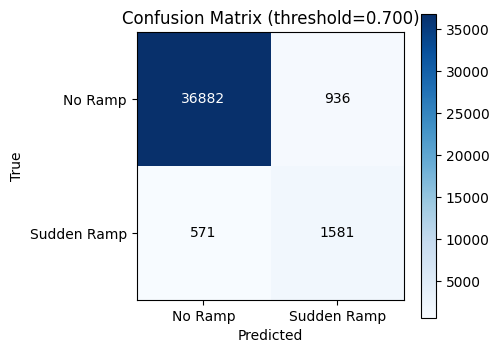

==== RAMPS POSITIFS vs NÉGATIFS ====
Vrais ramps positifs  : 940
Vrais ramps négatifs  : 1212
Détectés positifs     : 762
Détectés négatifs     : 804
Recall ramp positif   : 0.810638
Recall ramp négatif   : 0.663366


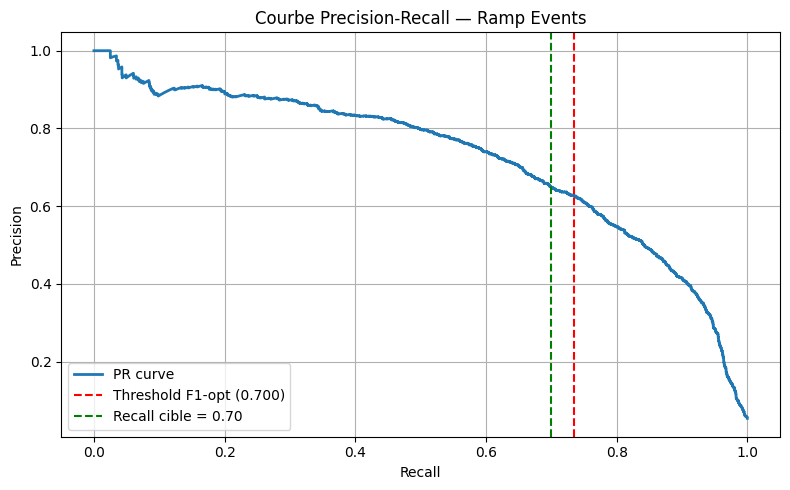

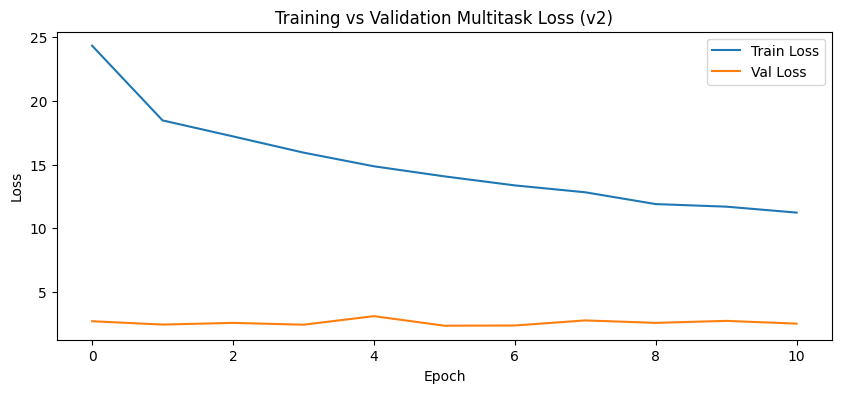

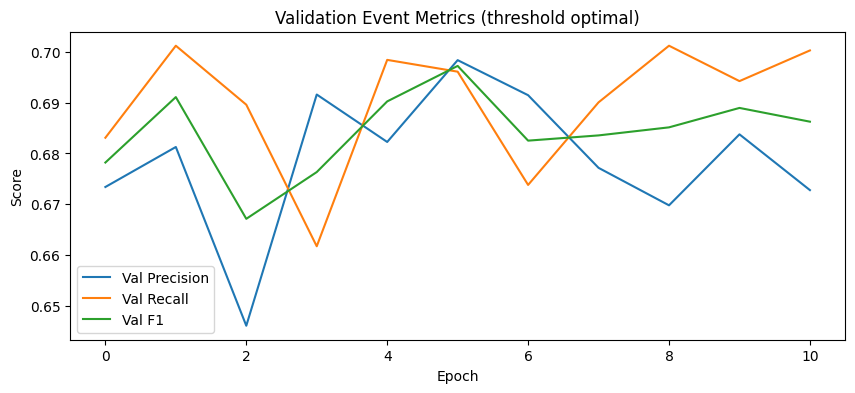

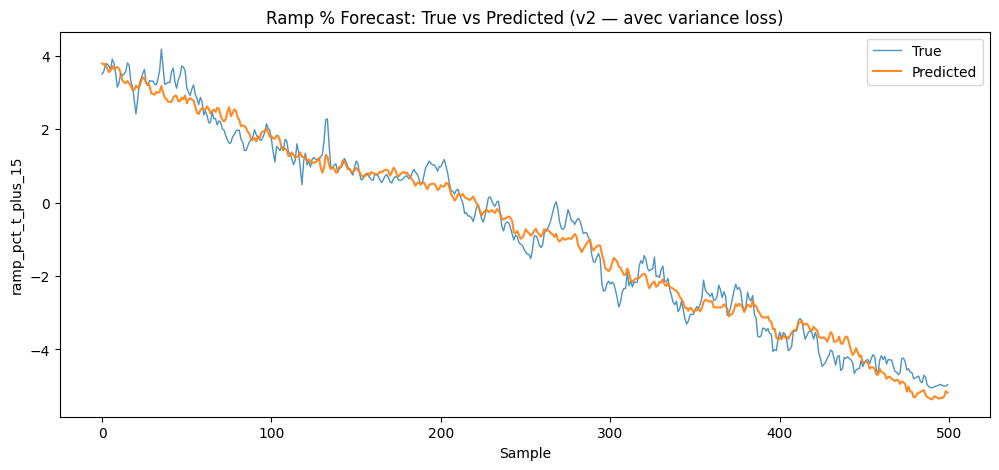


--- Vérification Fix C (variance) ---
Std True       : 5.6536
Std Predicted  : 5.6967
Ratio std P/T  : 1.0076  (cible: proche de 1.0)

Modèle sauvegardé : /kaggle/working/multitask_ramp_v2_resnet_gru.pth
Scaler sauvegardé : /kaggle/working/multitask_ramp_v2_scaler.pkl

RÉSUMÉ FINAL — MULTITASK RAMP V2
  MAE              : 1.348431
  RMSE             : 3.152226
  R²               : 0.689125
  --- Threshold F1-optimal (0.700) ---
  Precision        : 0.628129
  Recall           : 0.734665
  F1               : 0.677233
  --- Threshold Recall≥0.70 (0.721) ---
  Precision        : 0.648730
  Recall           : 0.700279
  F1               : 0.673520


In [ ]:
# ============================================================
# Multimodal Short-Term Solar Ramp Forecasting
# Objective:
# Predict the PV power ramp 15 minutes ahead using:
#   1. sky image sequences,
#   2. historical PV values,
#   3. meteorological data.
#
# The model has two outputs:
#   - regression: expected ramp magnitude in %
#   - classification: probability of a sudden ramp event
# ============================================================

# ==============================
# 1. Configuration & Setup
# ==============================

# !pip -q install torchvision joblib scipy

import copy
import math
import random
import warnings

import h5py
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_recall_curve,
    precision_score,
    recall_score,
    r2_score,
)
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights

warnings.filterwarnings("ignore")

# ============================================================
# Seed & Device
# ============================================================
SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

# ============================================================
# Paths
# ============================================================
TIMES_PATH   = "/kaggle/input/datasets/marghedranim/skippd/times_trainval.npy"
H5_PATH      = "/kaggle/input/datasets/marghedranim/skippd/2017_2019_images_pv_processed.hdf5"
WEATHER_CSV  = "/kaggle/input/datasets/marghedranim/skippd/weather_stanford_2017_2019.csv"

# ============================================================
# Hyperparameters
# ============================================================
SEQ_LEN               = 15
HORIZON               = 15
N_LAGS                = 15
RAMP_EVENT_QUANTILE   = 0.90
BATCH_SIZE            = 8
NUM_WORKERS           = 2

EPOCHS_STAGE1         = 20
EPOCHS_STAGE2         = 10
LR_STAGE1             = 1e-4
LR_STAGE2_BACKBONE    = 1e-5
LR_STAGE2_HEADS       = 2e-5
WEIGHT_DECAY          = 1e-4
EARLY_STOPPING_PATIENCE = 5
GRAD_CLIP_MAX_NORM    = 1.0

USE_SUBSET            = True
MAX_SAMPLES           = 200000
TRAIN_RATIO           = 0.8
SPLIT_GAP             = SEQ_LEN + HORIZON

# Loss weights used to balance the regression and classification objectives
REG_LOSS_WEIGHT       = 1.0
CLS_LOSS_WEIGHT       = 1.0
VARIANCE_LOSS_WEIGHT  = 0.2

# Weighted sampling is used to reduce the effect of class imbalance
USE_WEIGHTED_SAMPLER  = True

MODEL_SAVE_PATH  = "/kaggle/working/multitask_ramp_v2_resnet_gru.pth"
SCALER_SAVE_PATH = "/kaggle/working/multitask_ramp_v2_scaler.pkl"

# ==============================
# 2. Data Preparation
# ==============================

# ============================================================
# Build dataframe
# ============================================================
times = np.load(TIMES_PATH, allow_pickle=True)
df = pd.DataFrame({"timestamp": pd.to_datetime(times)})
df["timestamp"] = df["timestamp"].dt.tz_localize("America/Los_Angeles")
df = df.sort_values("timestamp").reset_index(drop=True)

with h5py.File(H5_PATH, "r") as f:
    df["pv_log"] = f["trainval"]["pv_log"][:]

df["sample_idx"] = np.arange(len(df))
print(df.shape)

# ============================================================
# Merge weather
# ============================================================
df_weather = pd.read_csv(WEATHER_CSV)
df_weather["timestamp"] = pd.to_datetime(df_weather["timestamp"], utc=True)
df_weather["timestamp"] = df_weather["timestamp"].dt.tz_convert("America/Los_Angeles")
df_weather = df_weather.sort_values("timestamp").reset_index(drop=True)
df_weather = df_weather.rename(columns={"timestamp": "weather_timestamp"})

df = pd.merge_asof(
    df,
    df_weather,
    left_on="timestamp",
    right_on="weather_timestamp",
    direction="backward",
)
df["weather_age_min"] = (
    (df["timestamp"] - df["weather_timestamp"]).dt.total_seconds() / 60.0
)

# ============================================================
# Features
# ============================================================
df["pv_t_plus_15"] = df["pv_log"].shift(-HORIZON)
lag_cols = [f"pv_log_lag_{lag}" for lag in range(N_LAGS)]
for lag_col, lag in zip(lag_cols, range(N_LAGS)):
    df[lag_col] = df["pv_log"].shift(lag)

df["hour"]      = df["timestamp"].dt.hour
df["dayofyear"] = df["timestamp"].dt.dayofyear
df["hour_sin"]  = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"]  = np.cos(2 * np.pi * df["hour"] / 24)
df["doy_sin"]   = np.sin(2 * np.pi * df["dayofyear"] / 365)
df["doy_cos"]   = np.cos(2 * np.pi * df["dayofyear"] / 365)
df["WD2M_sin"]  = np.sin(2 * np.pi * df["WD2M"] / 360)
df["WD2M_cos"]  = np.cos(2 * np.pi * df["WD2M"] / 360)

# Rate of change (first-order derivative)
df["pv_velocity"]   = df["pv_log"].diff(1)

# Acceleration (2nd order derivative)
df["pv_accel"]      = df["pv_log"].diff(1) - df["pv_log"].shift(1).diff(1)

# Local volatility — standard over the last 5 minutes
df["pv_local_std"]  = df["pv_log"].rolling(5, min_periods=1).std().fillna(0)

# Deviation from the moving average — detects abnormal deviations
df["pv_ma15"]       = df["pv_log"].rolling(15, min_periods=1).mean()
df["pv_deviation"]  = df["pv_log"] - df["pv_ma15"]

# Recent 10-minute max-min range — amplitude of variations
df["pv_range_10"]   = (
    df["pv_log"].rolling(10, min_periods=1).max()
    - df["pv_log"].rolling(10, min_periods=1).min()
)


pv_array = df["pv_log"].values
# window_length must be odd and < len(series)
wl = min(61, len(pv_array) - 1)
if wl % 2 == 0:
    wl -= 1
pv_smooth = savgol_filter(pv_array, window_length=wl, polyorder=2)
df["pv_detrended"]  = pv_array - pv_smooth

print("Nouvelles features précurseurs ajoutées ✓")


df = df.dropna(subset=["pv_t_plus_15"] + lag_cols).reset_index(drop=True)
df = df[df["sample_idx"] >= SEQ_LEN - 1].reset_index(drop=True)

# ============================================================
# Feature cols
# ============================================================
feature_cols = [
    *[f"pv_log_lag_{i}" for i in range(N_LAGS)],
    "T2M", "RH2M", "PS", "WS2M",
    "PRECTOTCORR", "ALLSKY_SFC_SW_DWN",
    "WD2M_sin", "WD2M_cos", "weather_age_min",
    "hour_sin", "hour_cos", "doy_sin", "doy_cos",
    "pv_velocity", "pv_accel", "pv_local_std",
    "pv_deviation", "pv_range_10", "pv_detrended",
]
print(f"Nombre de features : {len(feature_cols)}")
print(feature_cols)

# ============================================================
# Chronological split
# ============================================================
df_model = df.copy()
if USE_SUBSET:
    df_model = df_model.iloc[:MAX_SAMPLES].reset_index(drop=True)

split_idx  = int(len(df_model) * TRAIN_RATIO)
train_end  = max(split_idx - SPLIT_GAP, 1)
val_start  = min(split_idx + SPLIT_GAP, len(df_model) - 1)
df_train   = df_model.iloc[:train_end].reset_index(drop=True)
df_val     = df_model.iloc[val_start:].reset_index(drop=True)

print("Train:", df_train.shape)
print("Val  :", df_val.shape)
print("Train range:", df_train["timestamp"].min(), "->", df_train["timestamp"].max())
print("Val range  :", df_val["timestamp"].min(),   "->", df_val["timestamp"].max())
print("Gap        :", df_val["timestamp"].min() - df_train["timestamp"].max())

# ============================================================
# Targets: ramp_pct and sudden_ramp
# ============================================================
P_MAX_TRAIN = df_train["pv_log"].max()
for part in [df_train, df_val]:
    part["ramp_pct_t_plus_15"] = (
        (part["pv_t_plus_15"] - part["pv_log"]) / P_MAX_TRAIN
    ) * 100.0
    part["abs_ramp_pct"] = part["ramp_pct_t_plus_15"].abs()

RAMP_THRESHOLD = float(df_train["abs_ramp_pct"].quantile(RAMP_EVENT_QUANTILE))
for part in [df_train, df_val]:
    part["sudden_ramp"] = (part["abs_ramp_pct"] >= RAMP_THRESHOLD).astype(int)

print(f"P_MAX_TRAIN         : {P_MAX_TRAIN}")
print(f"RAMP_THRESHOLD      : {RAMP_THRESHOLD:.4f}")
print(f"Train sudden-ramp % : {df_train['sudden_ramp'].mean():.4f}")
print(f"Val sudden-ramp %   : {df_val['sudden_ramp'].mean():.4f}")

# ============================================================
# Scaling
# ============================================================
scaler = StandardScaler()
df_train_scaled = df_train.copy()
df_val_scaled   = df_val.copy()
df_train_scaled[feature_cols] = scaler.fit_transform(df_train[feature_cols])
df_val_scaled[feature_cols]   = scaler.transform(df_val[feature_cols])
joblib.dump(scaler, SCALER_SAVE_PATH)
print("Scaler sauvegardé :", SCALER_SAVE_PATH)

# ============================================================
# Dataset
# ============================================================
weights_pretrain = ResNet18_Weights.DEFAULT
imagenet_mean    = weights_pretrain.transforms().mean
imagenet_std     = weights_pretrain.transforms().std

common_transforms = [
    transforms.ToPILImage(),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
]
train_transform = transforms.Compose(common_transforms)
val_transform   = transforms.Compose(common_transforms)


class SolarSequenceDataset(Dataset):
    def __init__(self, dataframe, h5_path, feature_cols, seq_len=12,
                 transform=None, group_name="trainval"):
        self.df           = dataframe.reset_index(drop=True)
        self.h5_path      = h5_path
        self.feature_cols = feature_cols
        self.seq_len      = seq_len
        self.transform    = transform
        self.group_name   = group_name
        self.h5_file      = None

    def __len__(self):
        return len(self.df)

    def _get_h5(self):
        if self.h5_file is None:
            self.h5_file = h5py.File(self.h5_path, "r")
        return self.h5_file

    def __getitem__(self, idx):
        row        = self.df.iloc[idx]
        sample_idx = int(row["sample_idx"])
        start_idx  = sample_idx - self.seq_len + 1
        end_idx    = sample_idx + 1

        h5f      = self._get_h5()
        seq_imgs = h5f[self.group_name]["images_log"][start_idx:end_idx]

        images = []
        for img in seq_imgs:
            if self.transform is not None:
                img = self.transform(img)
            else:
                img = torch.tensor(img.transpose(2, 0, 1), dtype=torch.float32) / 255.0
            images.append(img)
        images = torch.stack(images, dim=0)

        tabular = torch.tensor(
            row[self.feature_cols].to_numpy(dtype=np.float32), dtype=torch.float32
        )
        y_reg = torch.tensor(row["ramp_pct_t_plus_15"], dtype=torch.float32)
        y_cls = torch.tensor(row["sudden_ramp"],        dtype=torch.float32)
        return images, tabular, y_reg, y_cls


train_dataset = SolarSequenceDataset(
    dataframe=df_train_scaled, h5_path=H5_PATH, feature_cols=feature_cols,
    seq_len=SEQ_LEN, transform=train_transform, group_name="trainval",
)
val_dataset = SolarSequenceDataset(
    dataframe=df_val_scaled, h5_path=H5_PATH, feature_cols=feature_cols,
    seq_len=SEQ_LEN, transform=val_transform, group_name="trainval",
)


if USE_WEIGHTED_SAMPLER:
    class_counts   = df_train_scaled["sudden_ramp"].value_counts().sort_index()
    sample_weights = df_train_scaled["sudden_ramp"].map(
        {0: 1.0 / class_counts[0], 1: 1.0 / class_counts[1]}
    ).to_numpy()
    sampler = WeightedRandomSampler(
        sample_weights, num_samples=len(sample_weights), replacement=True
    )
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, sampler=sampler, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True,
        persistent_workers=NUM_WORKERS > 0,
    )
    print("WeightedRandomSampler activé ✓")
else:
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True,
        persistent_workers=NUM_WORKERS > 0,
    )

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=NUM_WORKERS > 0,
)

images, tabular, y_reg, y_cls = next(iter(train_loader))
print("images  :", images.shape)
print("tabular :", tabular.shape)
print("y_reg   :", y_reg.shape)
print("y_cls   :", y_cls.shape)


# ==============================
# 3. Model Architecture
# ==============================
# ============================================================
# Multimodal model combining:
# - CNN for image features
# - GRU for temporal sequences
# - MLP for tabular data
# - Fusion for final prediction
# ============================================================

class MultimodalForecastNet(nn.Module):
    def __init__(self, tabular_dim, img_embed_dim=128, tab_embed_dim=64,
                 gru_hidden_dim=128):
        super().__init__()
        self.backbone = models.resnet18(weights=ResNet18_Weights.DEFAULT)
        self.backbone.fc = nn.Identity()

        self.frame_proj = nn.Sequential(
            nn.Linear(512, img_embed_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
        )
        self.gru = nn.GRU(
            input_size=img_embed_dim,
            hidden_size=gru_hidden_dim,
            num_layers=1,
            batch_first=True,
        )
        self.tabular_encoder = nn.Sequential(
            nn.Linear(tabular_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, tab_embed_dim),
            nn.ReLU(),
        )
        fusion_dim = gru_hidden_dim + tab_embed_dim
        self.fusion = nn.Sequential(
            nn.Linear(fusion_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
        )

        self.reg_head = nn.Linear(64, 1)


        self.cls_head = nn.Sequential(
            nn.Linear(fusion_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, images, tabular):
        B, T, C, H, W = images.shape
        x = images.view(B * T, C, H, W)
        frame_feats = self.backbone(x)
        frame_feats = self.frame_proj(frame_feats)
        frame_feats = frame_feats.view(B, T, -1)
        _, h_n = self.gru(frame_feats)
        img_seq_feat = h_n[-1]

        tab_feat = self.tabular_encoder(tabular)
        fused_raw = torch.cat([img_seq_feat, tab_feat], dim=1)

        fused = self.fusion(fused_raw)

        y_reg       = self.reg_head(fused).squeeze(1)
        y_cls_logit = self.cls_head(fused_raw).squeeze(1)

        return y_reg, y_cls_logit


model = MultimodalForecastNet(tabular_dim=len(feature_cols)).to(device)
print(model)

# ============================================================
# Positive class weight to handle imbalance between normal and sudden-ramp events
# ============================================================
pos_count      = float(df_train_scaled["sudden_ramp"].sum())
neg_count      = float(len(df_train_scaled) - pos_count)
raw_pos_weight = neg_count / max(pos_count, 1.0)

pos_weight     = torch.tensor([raw_pos_weight], dtype=torch.float32, device=device)
print(f"raw_pos_weight  : {raw_pos_weight:.4f}")
print(f"used_pos_weight : {pos_weight.item():.4f}  (plus de cap à 4.0)")

# ==============================
# 4. Loss Functions
# ==============================
# ==============================
# Regression loss: predicts ramp magnitude
# Classification loss: detects sudden ramps
# Variance term: prevents overly smooth predictions
# ==============================

# ============================================================
# Focal Loss: focuses the classifier on difficult and rare ramp-event samples
# ============================================================
class FocalLoss(nn.Module):
    """
    Focal loss for unbalanced datasets.
    Alpha: weighting of positive values ​​(ramps)
    Gamma: focusing factor on difficult examples
    """
    def __init__(self, alpha=0.75, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha     = alpha
        self.gamma     = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        bce    = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs  = torch.sigmoid(logits)
        pt     = torch.where(targets == 1, probs, 1.0 - probs)
        alpha_t = torch.where(
            targets == 1,
            torch.tensor(self.alpha,       device=logits.device),
            torch.tensor(1.0 - self.alpha, device=logits.device),
        )
        focal_weight = alpha_t * (1.0 - pt) ** self.gamma
        loss = focal_weight * bce

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss


cls_criterion = FocalLoss(alpha=0.75, gamma=2.0)
print("Focal Loss activée ✓")

# ============================================================
# Asymmetric regression loss: penalizes large ramp errors more strongly
# ============================================================
class AsymmetricRampLoss(nn.Module):
    """
    Penalizes errors on true ramp events
    alpha times more than on non-ramps.
    """
    def __init__(self, ramp_threshold, alpha=3.0, delta=1.0):
        super().__init__()
        self.ramp_threshold = ramp_threshold
        self.alpha          = alpha
        self.delta          = delta

    def forward(self, pred, target):
        base_loss = F.huber_loss(pred, target, delta=self.delta, reduction="none")
        is_ramp   = (target.abs() >= self.ramp_threshold).float()
        weights   = 1.0 + (self.alpha - 1.0) * is_ramp
        return (weights * base_loss).mean()


reg_criterion = AsymmetricRampLoss(ramp_threshold=RAMP_THRESHOLD, alpha=3.0)
print(f"AsymmetricRampLoss activée (alpha=3.0, threshold={RAMP_THRESHOLD:.4f}) ✓")

# ============================================================
# Combined multi-task loss: regression + classification + variance consistency
# ============================================================
def multitask_loss(pred_reg, y_reg, pred_cls_logit, y_cls):
    reg_loss = reg_criterion(pred_reg, y_reg)
    cls_loss = cls_criterion(pred_cls_logit, y_cls)


    pred_std  = pred_reg.std()
    true_std  = y_reg.std().detach()
    var_loss  = F.mse_loss(pred_std, true_std)

    total = (
        REG_LOSS_WEIGHT      * reg_loss
        + CLS_LOSS_WEIGHT    * cls_loss
        + VARIANCE_LOSS_WEIGHT * var_loss
    )
    return total, reg_loss, cls_loss, var_loss


# ==============================
# 5. Metrics
# ==============================

def regression_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return mae, rmse, r2


def classification_metrics(y_true, y_prob, threshold=0.5):
    y_pred    = (y_prob >= threshold).astype(int)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)
    return precision, recall, f1, y_pred



def find_optimal_threshold(y_true, y_prob, strategy="f1"):
    """
    strategy = 'f1' → maximizes F1
    strategy = 'recall' → recall >= 0.70 with the best possible accuracy
    """
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    if strategy == "f1":
        f1_scores = (
            2 * precisions * recalls / (precisions + recalls + 1e-8)
        )
        best_idx = np.argmax(f1_scores)
        return float(thresholds[best_idx]), float(f1_scores[best_idx])
    elif strategy == "recall":
        target_recall = 0.70
        valid = recalls[:-1] >= target_recall
        if valid.any():
            best_idx = np.where(valid)[0][-1]
            return float(thresholds[best_idx]), float(recalls[best_idx])
        return 0.3, 0.0

# ==============================
# 6. Training Loop
# ==============================

# ============================================================
# Optimizer Stage 1 (frozen backbone)
# ============================================================
for p in model.backbone.parameters():
    p.requires_grad = False

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_STAGE1,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=1,
)

# ============================================================
# Functions train / eval
# ============================================================
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = total_reg = total_cls = total_var = 0.0

    for batch_idx, (images, tabular, y_reg, y_cls) in enumerate(loader):
        images  = images.to(device,  non_blocking=True)
        tabular = tabular.to(device, non_blocking=True)
        y_reg   = y_reg.to(device,   non_blocking=True)
        y_cls   = y_cls.to(device,   non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        pred_reg, pred_cls_logit = model(images, tabular)
        loss, reg_loss, cls_loss, var_loss = multitask_loss(
            pred_reg, y_reg, pred_cls_logit, y_cls
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_MAX_NORM)
        optimizer.step()

        bs = images.size(0)
        total_loss += loss.item()     * bs
        total_reg  += reg_loss.item() * bs
        total_cls  += cls_loss.item() * bs
        total_var  += var_loss.item() * bs

        if batch_idx % 200 == 0:
            print(
                f"Train batch {batch_idx}/{len(loader)} | "
                f"loss={loss.item():.4f} | reg={reg_loss.item():.4f} | "
                f"cls={cls_loss.item():.4f} | var={var_loss.item():.4f}"
            )

    n = len(loader.dataset)
    return total_loss / n, total_reg / n, total_cls / n, total_var / n


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss = total_reg = total_cls = total_var = 0.0
    all_reg_preds = []
    all_reg_targets = []
    all_cls_logits = []
    all_cls_targets = []

    for batch_idx, (images, tabular, y_reg, y_cls) in enumerate(loader):
        images  = images.to(device,  non_blocking=True)
        tabular = tabular.to(device, non_blocking=True)
        y_reg   = y_reg.to(device,   non_blocking=True)
        y_cls   = y_cls.to(device,   non_blocking=True)

        pred_reg, pred_cls_logit = model(images, tabular)
        loss, reg_loss, cls_loss, var_loss = multitask_loss(
            pred_reg, y_reg, pred_cls_logit, y_cls
        )

        bs = images.size(0)
        total_loss += loss.item()     * bs
        total_reg  += reg_loss.item() * bs
        total_cls  += cls_loss.item() * bs
        total_var  += var_loss.item() * bs

        all_reg_preds.append(pred_reg.cpu().numpy())
        all_reg_targets.append(y_reg.cpu().numpy())
        all_cls_logits.append(pred_cls_logit.cpu().numpy())
        all_cls_targets.append(y_cls.cpu().numpy())

        if batch_idx % 200 == 0:
            print(f"Val batch {batch_idx}/{len(loader)}")

    all_reg_preds   = np.concatenate(all_reg_preds)
    all_reg_targets = np.concatenate(all_reg_targets)
    all_cls_logits  = np.concatenate(all_cls_logits)
    all_cls_probs   = 1.0 / (1.0 + np.exp(-all_cls_logits))
    all_cls_targets = np.concatenate(all_cls_targets).astype(int)

    return {
        "loss"       : total_loss / len(loader.dataset),
        "reg_loss"   : total_reg  / len(loader.dataset),
        "cls_loss"   : total_cls  / len(loader.dataset),
        "var_loss"   : total_var  / len(loader.dataset),
        "reg_preds"  : all_reg_preds,
        "reg_targets": all_reg_targets,
        "cls_probs"  : all_cls_probs,
        "cls_targets": all_cls_targets,
    }

# ============================================================
# Baseline persistance
# ============================================================
baseline_targets   = df_val_scaled["ramp_pct_t_plus_15"].to_numpy(dtype=np.float32)
baseline_preds     = np.zeros_like(baseline_targets)
baseline_mae, baseline_rmse, baseline_r2 = regression_metrics(baseline_targets, baseline_preds)
baseline_true_event = df_val_scaled["sudden_ramp"].to_numpy(dtype=int)
baseline_prob       = np.zeros_like(baseline_targets)
baseline_prec, baseline_rec, baseline_f1, _ = classification_metrics(
    baseline_true_event, baseline_prob, threshold=0.5
)
print("==== PERSISTENCE BASELINE ====")
print(f"MAE       : {baseline_mae:.6f}")
print(f"RMSE      : {baseline_rmse:.6f}")
print(f"R2        : {baseline_r2:.6f}")
print(f"Precision : {baseline_prec:.6f}")
print(f"Recall    : {baseline_rec:.6f}")
print(f"F1        : {baseline_f1:.6f}")

# ============================================================
# Stage 1 — frozen backbone
# ============================================================
history = {
    "train_loss": [], "train_reg_loss": [], "train_cls_loss": [], "train_var_loss": [],
    "val_loss":   [], "val_reg_loss":   [], "val_cls_loss":   [],
    "val_mae":    [], "val_rmse":       [], "val_r2":         [],
    "val_precision": [], "val_recall":  [], "val_f1":         [],
}

best_val_loss  = float("inf")
best_state     = None
patience_counter = 0

for epoch in range(EPOCHS_STAGE1):
    train_loss, train_reg, train_cls, train_var = train_one_epoch(
        model, train_loader, optimizer, device
    )
    val_out = evaluate(model, val_loader, device)
    scheduler.step(val_out["loss"])


    opt_threshold, _ = find_optimal_threshold(
        val_out["cls_targets"], val_out["cls_probs"], strategy="f1"
    )
    mae, rmse, r2    = regression_metrics(val_out["reg_targets"], val_out["reg_preds"])
    precision, recall, f1, _ = classification_metrics(
        val_out["cls_targets"], val_out["cls_probs"], threshold=opt_threshold
    )

    history["train_loss"].append(train_loss)
    history["train_reg_loss"].append(train_reg)
    history["train_cls_loss"].append(train_cls)
    history["train_var_loss"].append(train_var)
    history["val_loss"].append(val_out["loss"])
    history["val_reg_loss"].append(val_out["reg_loss"])
    history["val_cls_loss"].append(val_out["cls_loss"])
    history["val_mae"].append(mae)
    history["val_rmse"].append(rmse)
    history["val_r2"].append(r2)
    history["val_precision"].append(precision)
    history["val_recall"].append(recall)
    history["val_f1"].append(f1)

    if val_out["loss"] < best_val_loss:
        best_val_loss = val_out["loss"]
        best_state    = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    print(
        f"[Stage 1 - Epoch {epoch+1}/{EPOCHS_STAGE1}] "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_out['loss']:.4f} | "
        f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f} | "
        f"Threshold: {opt_threshold:.3f} | "
        f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}"
    )

    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print("Stage 1 early stopping triggered")
        break

# ============================================================
# Stage 2 — fine-tuning layer4
# ============================================================
stage2_history = {
    "val_loss": [], "val_mae": [], "val_rmse": [], "val_r2": [],
    "val_precision": [], "val_recall": [], "val_f1": [],
}

model.load_state_dict(best_state)
for p in model.backbone.parameters():
    p.requires_grad = False
for p in model.backbone.layer4.parameters():
    p.requires_grad = True
for module in [model.frame_proj, model.gru, model.tabular_encoder,
               model.fusion, model.reg_head, model.cls_head]:
    for p in module.parameters():
        p.requires_grad = True

optimizer_stage2 = torch.optim.AdamW([
    {"params": model.backbone.layer4.parameters(),    "lr": LR_STAGE2_BACKBONE},
    {"params": model.frame_proj.parameters(),         "lr": LR_STAGE2_HEADS},
    {"params": model.gru.parameters(),                "lr": LR_STAGE2_HEADS},
    {"params": model.tabular_encoder.parameters(),    "lr": LR_STAGE2_HEADS},
    {"params": model.fusion.parameters(),             "lr": LR_STAGE2_HEADS},
    {"params": model.reg_head.parameters(),           "lr": LR_STAGE2_HEADS},
    {"params": model.cls_head.parameters(),           "lr": LR_STAGE2_HEADS},
], weight_decay=WEIGHT_DECAY)

scheduler_stage2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_stage2, mode="min", factor=0.5, patience=1,
)

best_val_loss_stage2  = float("inf")
best_state_stage2     = None
patience_counter_stage2 = 0

for epoch in range(EPOCHS_STAGE2):
    train_loss, train_reg, train_cls, train_var = train_one_epoch(
        model, train_loader, optimizer_stage2, device
    )
    val_out = evaluate(model, val_loader, device)
    scheduler_stage2.step(val_out["loss"])

    opt_threshold, _ = find_optimal_threshold(
        val_out["cls_targets"], val_out["cls_probs"], strategy="f1"
    )
    mae, rmse, r2    = regression_metrics(val_out["reg_targets"], val_out["reg_preds"])
    precision, recall, f1, _ = classification_metrics(
        val_out["cls_targets"], val_out["cls_probs"], threshold=opt_threshold
    )

    stage2_history["val_loss"].append(val_out["loss"])
    stage2_history["val_mae"].append(mae)
    stage2_history["val_rmse"].append(rmse)
    stage2_history["val_r2"].append(r2)
    stage2_history["val_precision"].append(precision)
    stage2_history["val_recall"].append(recall)
    stage2_history["val_f1"].append(f1)

    if val_out["loss"] < best_val_loss_stage2:
        best_val_loss_stage2   = val_out["loss"]
        best_state_stage2      = copy.deepcopy(model.state_dict())
        patience_counter_stage2 = 0
    else:
        patience_counter_stage2 += 1

    print(
        f"[Stage 2 - Epoch {epoch+1}/{EPOCHS_STAGE2}] "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_out['loss']:.4f} | "
        f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f} | "
        f"Threshold: {opt_threshold:.3f} | "
        f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}"
    )

    if patience_counter_stage2 >= EARLY_STOPPING_PATIENCE:
        print("Stage 2 early stopping triggered")
        break

if best_state_stage2 is not None and best_val_loss_stage2 < best_val_loss:
    print("Stage 2 a amélioré Stage 1. Utilisation du meilleur Stage 2.")
    FINAL_BEST_STATE = copy.deepcopy(best_state_stage2)
else:
    print("Stage 2 n'a pas amélioré Stage 1. Conservation du meilleur Stage 1.")
    FINAL_BEST_STATE = copy.deepcopy(best_state)

model.load_state_dict(FINAL_BEST_STATE)

# ============================================================
# 7. Evaluation
# ============================================================

val_out = evaluate(model, val_loader, device)
mae, rmse, r2 = regression_metrics(val_out["reg_targets"], val_out["reg_preds"])


EVENT_THRESHOLD_F1, best_f1_score = find_optimal_threshold(
    val_out["cls_targets"], val_out["cls_probs"], strategy="f1"
)
EVENT_THRESHOLD_RECALL, _ = find_optimal_threshold(
    val_out["cls_targets"], val_out["cls_probs"], strategy="recall"
)

print(f"\nThreshold optimal (max F1)   : {EVENT_THRESHOLD_F1:.4f}")
print(f"Threshold optimal (recall≥70%): {EVENT_THRESHOLD_RECALL:.4f}")

# Results with threshold F1-optimal
precision_f1, recall_f1, f1_f1, y_pred_f1 = classification_metrics(
    val_out["cls_targets"], val_out["cls_probs"], threshold=EVENT_THRESHOLD_F1
)
# Results with optimal threshold recall
precision_r, recall_r, f1_r, y_pred_r = classification_metrics(
    val_out["cls_targets"], val_out["cls_probs"], threshold=EVENT_THRESHOLD_RECALL
)

print("\n==== RÉSULTATS FINAUX — Threshold optimisé F1 ====")
print(f"Loss      : {val_out['loss']:.6f}")
print(f"MAE       : {mae:.6f}")
print(f"RMSE      : {rmse:.6f}")
print(f"R2        : {r2:.6f}")
print(f"Precision : {precision_f1:.6f}")
print(f"Recall    : {recall_f1:.6f}")
print(f"F1        : {f1_f1:.6f}")

print("\n==== RÉSULTATS FINAUX — Threshold optimisé Recall≥0.70 ====")
print(f"Precision : {precision_r:.6f}")
print(f"Recall    : {recall_r:.6f}")
print(f"F1        : {f1_r:.6f}")

# Confusion matrix
cm = confusion_matrix(val_out["cls_targets"], y_pred_f1)
print("\n==== CONFUSION MATRIX (threshold F1-optimal) ====")
print(cm)
print("\n==== CLASSIFICATION REPORT ====")
print(classification_report(val_out["cls_targets"], y_pred_f1, digits=6, zero_division=0))

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title(f"Confusion Matrix (threshold={EVENT_THRESHOLD_F1:.3f})")
plt.colorbar()
labels = ["No Ramp", "Sudden Ramp"]
plt.xticks([0, 1], labels)
plt.yticks([0, 1], labels)
plt.xlabel("Predicted")
plt.ylabel("True")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.show()

# ============================================================
# Analysis of positive vs. negative ramps
# ============================================================
val_diag = pd.DataFrame({
    "y_true_ramp_pct": val_out["reg_targets"],
    "y_pred_ramp_pct": val_out["reg_preds"],
    "true_event"     : val_out["cls_targets"],
    "pred_event"     : y_pred_f1,
})
val_diag["true_direction"] = np.where(val_diag["y_true_ramp_pct"] >= 0, "positive", "negative")
val_diag["pred_direction"] = np.where(val_diag["y_pred_ramp_pct"] >= 0, "positive", "negative")

real_ramps  = val_diag[val_diag["true_event"] == 1].copy()
pos_real    = real_ramps[real_ramps["true_direction"] == "positive"]
neg_real    = real_ramps[real_ramps["true_direction"] == "negative"]
pos_detected = ((pos_real["pred_event"] == 1) & (pos_real["pred_direction"] == "positive")).sum()
neg_detected = ((neg_real["pred_event"] == 1) & (neg_real["pred_direction"] == "negative")).sum()

pos_recall_dir = pos_detected / len(pos_real) if len(pos_real) > 0 else 0.0
neg_recall_dir = neg_detected / len(neg_real) if len(neg_real) > 0 else 0.0

print("==== RAMPS POSITIFS vs NÉGATIFS ====")
print(f"Vrais ramps positifs  : {len(pos_real)}")
print(f"Vrais ramps négatifs  : {len(neg_real)}")
print(f"Détectés positifs     : {pos_detected}")
print(f"Détectés négatifs     : {neg_detected}")
print(f"Recall ramp positif   : {pos_recall_dir:.6f}")
print(f"Recall ramp négatif   : {neg_recall_dir:.6f}")

# ============================================================
# Precision-Recall Curve
# ============================================================
precisions, recalls, thresholds_pr = precision_recall_curve(
    val_out["cls_targets"], val_out["cls_probs"]
)
f1_curve = 2 * precisions * recalls / (precisions + recalls + 1e-8)

plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions, label="PR curve", linewidth=2)
plt.axvline(x=recall_f1, color="red",   linestyle="--", label=f"Threshold F1-opt ({EVENT_THRESHOLD_F1:.3f})")
plt.axvline(x=0.70,      color="green", linestyle="--", label="Recall cible = 0.70")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe Precision-Recall — Ramp Events")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# Training graphs
# ============================================================
plt.figure(figsize=(10, 4))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"],   label="Val Loss")
plt.title("Training vs Validation Multitask Loss (v2)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history["val_precision"], label="Val Precision")
plt.plot(history["val_recall"],    label="Val Recall")
plt.plot(history["val_f1"],        label="Val F1")
plt.title("Validation Event Metrics (threshold optimal)")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.show()

# ============================================================
# Ramp % Forecast: True vs Predicted (with volatility)
# ============================================================
plt.figure(figsize=(12, 5))
n_show = 500
plt.plot(val_out["reg_targets"][:n_show], label="True",      alpha=0.8, linewidth=1.0)
plt.plot(val_out["reg_preds"][:n_show],   label="Predicted", alpha=0.9, linewidth=1.5)
plt.title("Ramp % Forecast: True vs Predicted (v2 — avec variance loss)")
plt.xlabel("Sample")
plt.ylabel("ramp_pct_t_plus_15")
plt.legend()
plt.show()


print(f"\n--- Vérification Fix C (variance) ---")
print(f"Std True       : {val_out['reg_targets'].std():.4f}")
print(f"Std Predicted  : {val_out['reg_preds'].std():.4f}")
print(f"Ratio std P/T  : {val_out['reg_preds'].std() / val_out['reg_targets'].std():.4f}  (cible: proche de 1.0)")

# ============================================================
# Saving the final model
# ============================================================
torch.save({
    "model_state_dict"  : FINAL_BEST_STATE,
    "feature_cols"      : feature_cols,
    "seq_len"           : SEQ_LEN,
    "horizon"           : HORIZON,
    "ramp_threshold"    : RAMP_THRESHOLD,
    "p_max_train"       : P_MAX_TRAIN,
    "event_threshold_f1"    : EVENT_THRESHOLD_F1,
    "event_threshold_recall": EVENT_THRESHOLD_RECALL,
}, MODEL_SAVE_PATH)
joblib.dump(scaler, SCALER_SAVE_PATH)
print("\nModèle sauvegardé :", MODEL_SAVE_PATH)
print("Scaler sauvegardé :", SCALER_SAVE_PATH)

# ============================================================
# Final summary
# ============================================================
print("\n" + "="*55)
print("RÉSUMÉ FINAL — MULTITASK RAMP V2")
print("="*55)
print(f"  MAE              : {mae:.6f}")
print(f"  RMSE             : {rmse:.6f}")
print(f"  R²               : {r2:.6f}")
print(f"  --- Threshold F1-optimal ({EVENT_THRESHOLD_F1:.3f}) ---")
print(f"  Precision        : {precision_f1:.6f}")
print(f"  Recall           : {recall_f1:.6f}")
print(f"  F1               : {f1_f1:.6f}")
print(f"  --- Threshold Recall≥0.70 ({EVENT_THRESHOLD_RECALL:.3f}) ---")
print(f"  Precision        : {precision_r:.6f}")
print(f"  Recall           : {recall_r:.6f}")
print(f"  F1               : {f1_r:.6f}")
print("="*55)


XAI 1 — GradCAM++ (Sky Image Spatial Attention)
Cases found: ['TP+ (detected +ramp)', 'TP- (detected -ramp)', 'FN+ (missed +ramp)', 'FN- (missed -ramp)']


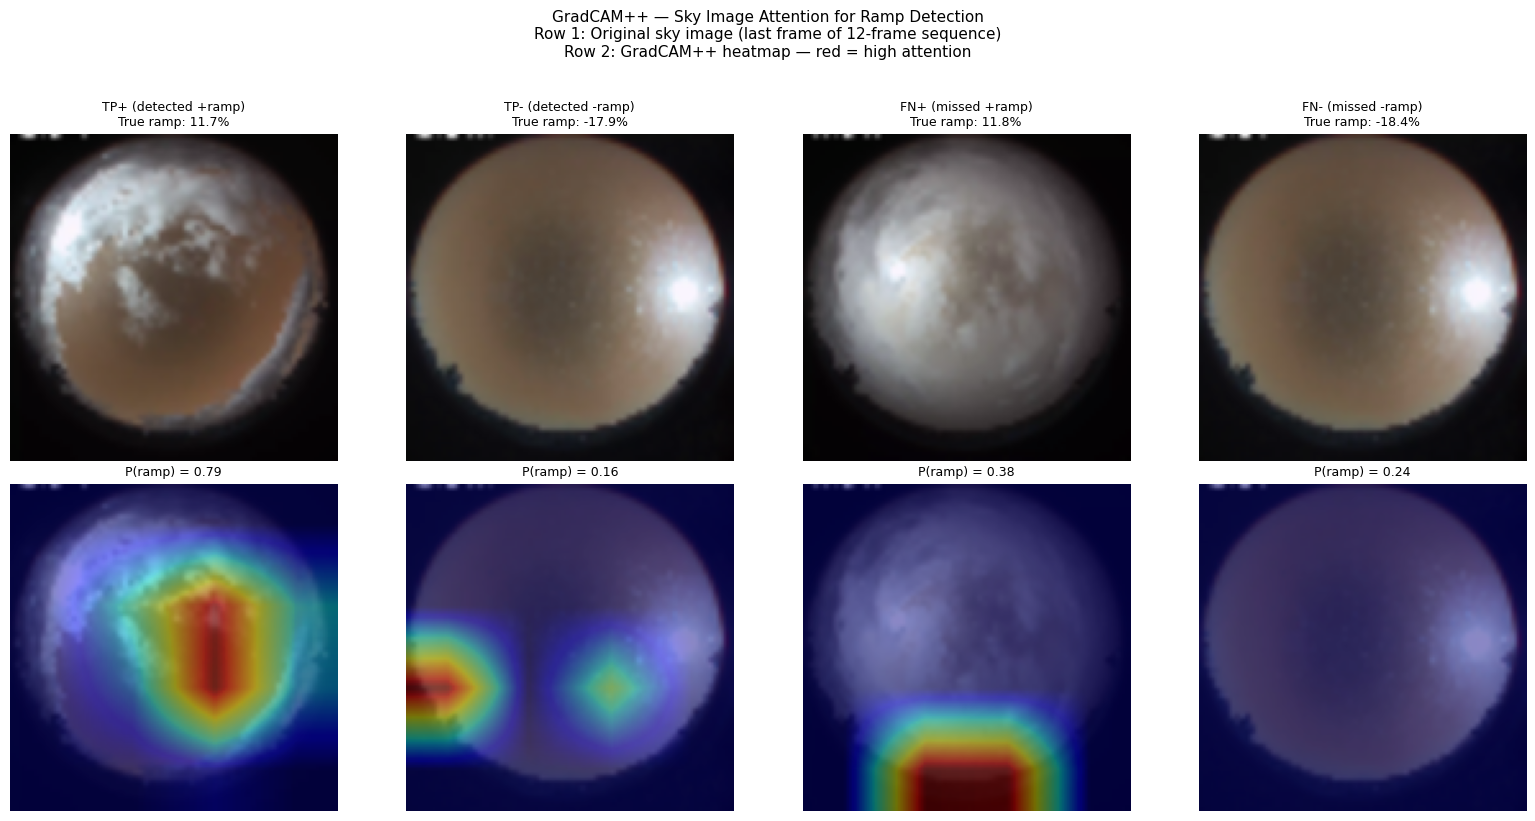

GradCAM++ saved ✓

XAI 2 — SHAP (Tabular Feature Attribution)


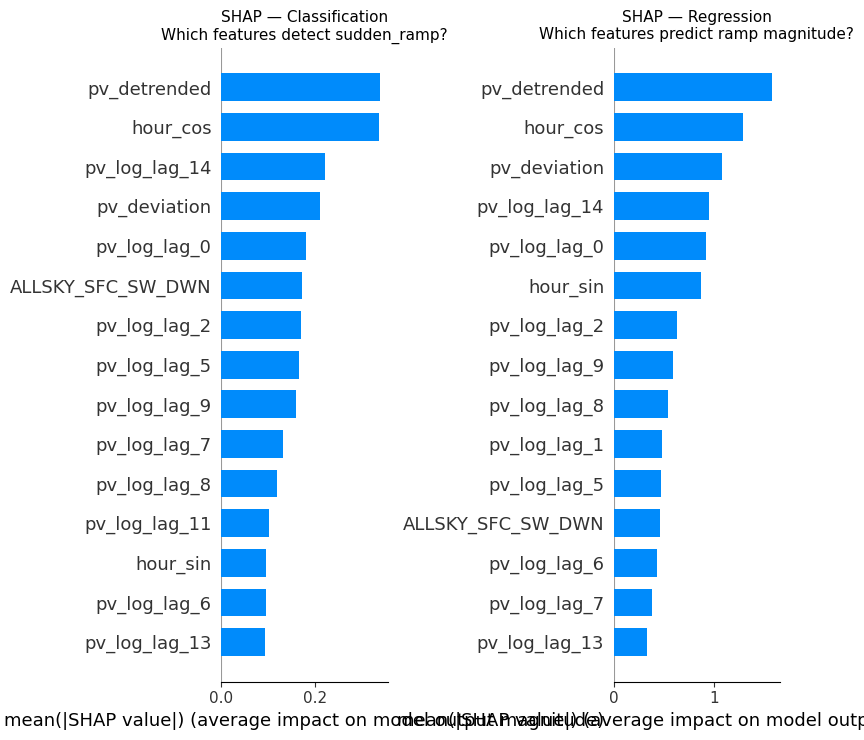

SHAP saved ✓

XAI 3 — Temporal Frame Importance
Does the model ANTICIPATE the ramp or REACT to it?
Analysing 10 True Positive events...

Most important frame : t-13
→ ANTICIPATES — early frames matter. Model sees cloud approaching. ✓


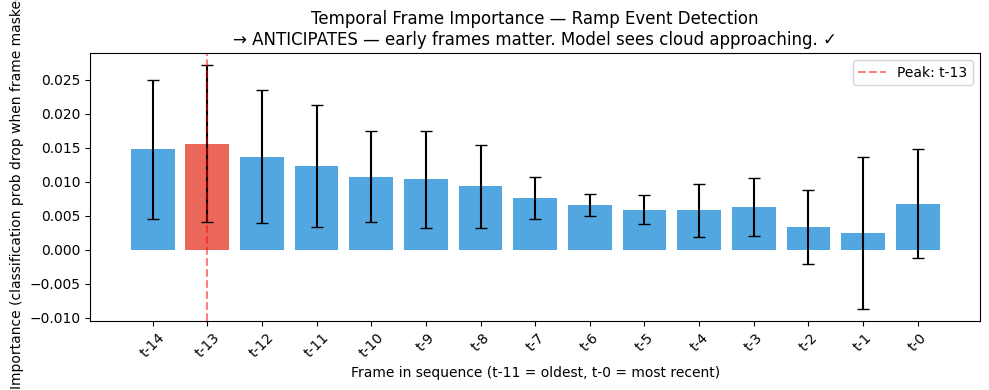


Temporal Importance Interpretation:
  Peak importance at t-13.
  Early frames dominant → model captures cloud movement
  patterns before the ramp — genuine early warning system.
  Last frame dominant  → model reacts to visible PV drop;
  consider increasing SEQ_LEN for better anticipation.
Temporal frame importance saved ✓


In [ ]:
# ==============================
# Explainability (XAI)
# ==============================
# ================================================================
# This section explains model predictions using:
# - GradCAM++: highlights important regions in sky images
# - SHAP: identifies important tabular features (PV + weather)
# - Temporal analysis: shows which frames influence predictions
# ================================================================

import shap
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# ================================================================
# XAI Block 1 — GradCAM++ on Sky Images
#
# Highlights which spatial regions of the LAST sky image frame
# drive the ramp detection decision.
# Target layer: layer4[-1].conv2 of ResNet18 (deepest semantic layer).
# ================================================================
print("\n" + "="*55)
print("XAI 1 — GradCAM++ (Sky Image Spatial Attention)")
print("="*55)


class GradCAMPlusPlus:
    """
    GradCAM++ applied to a target conv layer.
    Uses second-order gradient weighting for more precise
    localisation of small regions (e.g. cloud edges).
    IMPORTANT: call model.train() before use — GRU backward
    is not supported in eval() mode (cuDNN constraint).
    """
    def __init__(self, model, target_layer):
        self.model = model
        self.acts  = None
        self.grads = None
        self.fwd   = target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, "acts", o))
        self.bwd   = target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, "grads", go[0]))

    def remove(self):
        self.fwd.remove()
        self.bwd.remove()

    def generate(self, imgs_seq, cls_logit):
        self.model.zero_grad()
        cls_logit.backward(retain_graph=True)
        acts  = self.acts[0].detach()
        grads = self.grads[0].detach()
        alpha_num   = grads ** 2
        alpha_denom = (2 * grads**2
                       + (acts * grads**3).sum(dim=(1, 2), keepdim=True)
                       + 1e-8)
        alpha   = alpha_num / alpha_denom
        weights = (alpha * F.relu(grads)).sum(dim=(1, 2))
        cam     = (weights[:, None, None] * acts).sum(dim=0)
        cam     = F.relu(cam)
        cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        H, W    = imgs_seq.shape[-2], imgs_seq.shape[-1]
        cam     = F.interpolate(cam[None, None], size=(H, W),
                                mode="bilinear", align_corners=False)[0, 0]
        return cam.detach().cpu()


# ImageNet stats used in val_transform
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

def unnormalize(img_t):
    img = img_t.detach().cpu().permute(1, 2, 0).numpy()
    return np.clip(img * IMAGENET_STD + IMAGENET_MEAN, 0, 1)


# --- Build val diagnostic dataframe ---
val_diag = pd.DataFrame({
    "y_true" : val_out["reg_targets"],
    "true_ev": val_out["cls_targets"],
    "pred_ev": y_pred_f1,
})
val_diag["true_dir"] = np.where(val_diag["y_true"] >= 0, "pos", "neg")

def get_case(true_ev, pred_ev, direction):
    mask = ((val_diag["true_ev"]  == true_ev)  &
            (val_diag["pred_ev"]  == pred_ev)   &
            (val_diag["true_dir"] == direction))
    idxs = val_diag[mask].index
    return int(idxs[0]) if len(idxs) > 0 else None

cases = {
    "TP+ (detected +ramp)": get_case(1, 1, "pos"),
    "TP- (detected -ramp)": get_case(1, 1, "neg"),
    "FN+ (missed +ramp)"  : get_case(1, 0, "pos"),
    "FN- (missed -ramp)"  : get_case(1, 0, "neg"),
}
cases = {k: v for k, v in cases.items() if v is not None}
print(f"Cases found: {list(cases.keys())}")

# --- GradCAM++ visualisation ---
target_layer = model.backbone.layer4[-1].conv2
gradcam      = GradCAMPlusPlus(model, target_layer)

fig, axes = plt.subplots(2, len(cases), figsize=(4 * len(cases), 8))
fig.suptitle(
    "GradCAM++ — Sky Image Attention for Ramp Detection\n"
    "Row 1: Original sky image (last frame of 12-frame sequence)\n"
    "Row 2: GradCAM++ heatmap — red = high attention",
    fontsize=11, y=1.02
)

model.train()   # required for GRU backward pass
for col, (case_name, sample_idx) in enumerate(cases.items()):
    imgs, tab, y_reg, y_cls = val_dataset[sample_idx]
    imgs_t = imgs.unsqueeze(0).to(device)
    tab_t  = tab.unsqueeze(0).to(device)

    y_reg_out, cls_logit = model(imgs_t, tab_t)
    cam = gradcam.generate(imgs_t, cls_logit)

    last_frame = unnormalize(imgs[-1])   # most recent frame
    ax_img = axes[0, col] if len(cases) > 1 else axes[0]
    ax_cam = axes[1, col] if len(cases) > 1 else axes[1]

    ax_img.imshow(last_frame)
    ax_img.set_title(
        f"{case_name}\nTrue ramp: {y_reg.item():.1f}%",
        fontsize=9
    )
    ax_img.axis("off")

    ax_cam.imshow(last_frame)
    ax_cam.imshow(cam.numpy(), cmap="jet", alpha=0.45,
                  vmin=0, vmax=1)
    prob = torch.sigmoid(cls_logit).item()
    ax_cam.set_title(f"P(ramp) = {prob:.2f}", fontsize=9)
    ax_cam.axis("off")

gradcam.remove()
model.eval()

plt.tight_layout()
plt.savefig("/kaggle/working/xai_gradcam.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("GradCAM++ saved ✓")


# ================================================================
# XAI Block 2 — SHAP (Tabular Feature Importance)
#
# DeepExplainer on a TabularWrapper that:
#   1. Fixes the image branch with a mean GRU feature vector
#   2. Exposes only the tabular path for SHAP attribution
# ================================================================
print("\n" + "="*55)
print("XAI 2 — SHAP (Tabular Feature Attribution)")
print("="*55)


class TabularWrapper(nn.Module):
    """
    Isolates the tabular branch for SHAP analysis.
    Image branch is replaced by a fixed mean GRU feature vector,
    so SHAP attributes only the contribution of tabular features.

    V2 note: cls_head branches from fused_raw (GRU + tab concat),
    not from the shared fusion output.
    Output shape: [B, 2]  →  col 0 = reg logit, col 1 = cls logit
    """
    def __init__(self, model, mean_img_feat):
        super().__init__()
        self.model         = model
        self.mean_img_feat = mean_img_feat   # [1, gru_hidden=128]

    def forward(self, tabular):
        tab_f     = self.model.tabular_encoder(tabular)
        img_f     = self.mean_img_feat.expand(tabular.size(0), -1)
        fused_raw = torch.cat([img_f, tab_f], dim=1)   # [B, 192]

        fused     = self.model.fusion(fused_raw)        # [B, 64]
        reg       = self.model.reg_head(fused)          # [B, 1]


        cls       = self.model.cls_head(fused_raw)      # [B, 1]

        return torch.cat([reg, cls], dim=1)             # [B, 2]


# Compute mean GRU image feature over first 50 val batches
model.eval()
img_feats = []
with torch.no_grad():
    for i, (imgs, tab, yr, yc) in enumerate(val_loader):
        if i >= 50:
            break
        imgs = imgs.to(device)
        B, T, C, H, W = imgs.shape
        f = model.backbone(imgs.view(B * T, C, H, W))
        f = model.frame_proj(f).view(B, T, -1)
        _, h = model.gru(f)
        img_feats.append(h[-1].cpu())

mean_img_feat = (torch.stack(img_feats)
                 .mean(0).mean(0, keepdim=True).to(device))  # [1, 128]

tab_wrapper = TabularWrapper(model, mean_img_feat).to(device)
tab_wrapper.eval()

# Background and explanation samples
val_tab_np = df_val_scaled[feature_cols].values.astype(np.float32)
np.random.seed(42)
bg_idx  = np.random.choice(len(val_tab_np),  50, replace=False)
ex_idx  = np.random.choice(len(val_tab_np), 100, replace=False)

explainer   = shap.DeepExplainer(
    tab_wrapper,
    torch.tensor(val_tab_np[bg_idx]).to(device)
)
# check_additivity=False: avoids assertion error caused by Dropout
shap_values = explainer.shap_values(
    torch.tensor(val_tab_np[ex_idx]).to(device),
    check_additivity=False
)

# shap_values is list [reg_shap, cls_shap], each [100, n_features]
shap_cls = shap_values[1] if isinstance(shap_values, list) else shap_values[:, :, 1]
shap_reg = shap_values[0] if isinstance(shap_values, list) else shap_values[:, :, 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plt.sca(axes[0])
shap.summary_plot(shap_cls, val_tab_np[ex_idx],
                  feature_names=feature_cols,
                  plot_type="bar", show=False, max_display=15)
axes[0].set_title(
    "SHAP — Classification\nWhich features detect sudden_ramp?",
    fontsize=11
)

plt.sca(axes[1])
shap.summary_plot(shap_reg, val_tab_np[ex_idx],
                  feature_names=feature_cols,
                  plot_type="bar", show=False, max_display=15)
axes[1].set_title(
    "SHAP — Regression\nWhich features predict ramp magnitude?",
    fontsize=11
)

plt.tight_layout()
plt.savefig("/kaggle/working/xai_shap.png", dpi=150)
plt.show()
print("SHAP saved ✓")


# ================================================================
# XAI Block 3 — Temporal Frame Importance
#
# Masks one frame at a time (zero-out) across the 12-frame
# sequence and measures the resulting drop in ramp detection
# probability. Larger drop → frame is more important.
# ================================================================
print("\n" + "="*55)
print("XAI 3 — Temporal Frame Importance")
print("="*55)
print("Does the model ANTICIPATE the ramp or REACT to it?")

model.eval()

# Use True Positive events (correctly detected ramps)
tp_indices = val_diag[
    (val_diag["true_ev"] == 1) &
    (val_diag["pred_ev"] == 1)
].index.tolist()[:10]

print(f"Analysing {len(tp_indices)} True Positive events...")

all_imp = []
with torch.no_grad():
    for idx in tp_indices:
        imgs_i, tab_i, _, _ = val_dataset[idx]
        imgs_t = imgs_i.unsqueeze(0).to(device)
        tab_t  = tab_i.unsqueeze(0).to(device)

        _, base_cls = model(imgs_t, tab_t)
        base_prob   = torch.sigmoid(base_cls).item()

        scores = []
        for t in range(SEQ_LEN):
            masked       = imgs_t.clone()
            masked[0, t] = 0.0
            _, mc        = model(masked, tab_t)
            scores.append(base_prob - torch.sigmoid(mc).item())
        all_imp.append(scores)

mean_imp    = np.array(all_imp).mean(axis=0)
std_imp     = np.array(all_imp).std(axis=0)
time_labels = [f"t-{SEQ_LEN - 1 - i}" for i in range(SEQ_LEN)]
best_frame  = int(np.argmax(mean_imp))

print(f"\nMost important frame : {time_labels[best_frame]}")
if best_frame >= SEQ_LEN - 2:
    interp = "REACTS — last frame dominant. Model detects after ramp starts."
elif best_frame <= SEQ_LEN // 2:
    interp = "ANTICIPATES — early frames matter. Model sees cloud approaching. ✓"
else:
    interp = "MID-SEQUENCE — partial anticipation using recent visual context."
print(f"→ {interp}")

colors = ["#e74c3c" if i == best_frame else "#3498db"
          for i in range(SEQ_LEN)]
plt.figure(figsize=(10, 4))
plt.bar(range(SEQ_LEN), mean_imp, yerr=std_imp,
        capsize=4, color=colors, alpha=0.85)
plt.xticks(range(SEQ_LEN), time_labels, rotation=45)
plt.axvline(x=best_frame, color="red", linestyle="--", alpha=0.5,
            label=f"Peak: {time_labels[best_frame]}")
plt.xlabel("Frame in sequence (t-11 = oldest, t-0 = most recent)")
plt.ylabel("Importance (classification prob drop when frame masked)")
plt.title(
    f"Temporal Frame Importance — Ramp Event Detection\n→ {interp}"
)
plt.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/xai_temporal.png", dpi=150)
plt.show()

print("\nTemporal Importance Interpretation:")
print(f"  Peak importance at {time_labels[best_frame]}.")
print("  Early frames dominant → model captures cloud movement")
print("  patterns before the ramp — genuine early warning system.")
print("  Last frame dominant  → model reacts to visible PV drop;")
print("  consider increasing SEQ_LEN for better anticipation.")
print("Temporal frame importance saved ✓")